In [3]:
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt
import pandas as pd
import numpy  as np
import math, json

pd.set_option('display.max_columns', None)

In [4]:
OPTIONS = json.loads(open('../../info.json', 'r', encoding='utf-8').read())
OPTIONS

{'static_tests': {'target': 1, 'reference': 1},
 'dynamic_tests': {'target': 1, 'reference': 1}}

# IMPORTANDO DADOS

In [5]:
df_target = pd.read_csv('Target/output/data.csv')
df_target

,time,target_wy,target_yaw,target_pitch,target_ax,target_ay,target_q1,target_wz,target_q3,target_roll,target_q0,target_az,target_q2,target_wx,target_e
0,0.00,-91.70012,351.928,0.566,-0.204047,9.484855,0,-0.12853,0,-1.547,0,0.805861,0,-1.04879,0.0
1,0.01,-88.96987,351.027,0.544,-0.017211,9.935411,0,0.67168,0,-1.557,0,0.929719,0,-0.86342,0.0
2,0.02,-85.33893,349.281,0.496,0.149600,9.807072,0,1.19693,0,-1.572,0,-0.276293,0,-1.15715,0.0
3,0.03,-83.57597,348.434,0.471,0.693840,10.138713,0,0.28832,0,-1.589,0,0.036834,0,-0.06151,0.0
4,0.04,-82.54013,347.601,0.446,0.551869,9.821841,0,1.23804,0,-1.608,0,-0.058526,0,-0.63304,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4924,49.24,-0.83889,3.968,0.173,0.030538,9.802874,0,-0.80409,0,-0.554,0,-0.129222,0,-0.47394,0.0
4925,49.25,-1.29256,3.959,0.181,0.037854,9.860616,0,-0.63506,0,-0.562,0,-0.089241,0,-0.87732,0.0
4926,49.26,-1.10317,3.949,0.188,0.001638,9.865441,0,-0.50122,0,-0.568,0,-0.047994,0,-0.54886,0.0
4927,49.27,-1.04014,3.938,0.195,-0.039609,9.882289,0,-0.69446,0,-0.576,0,-0.045650,0,-0.71032,0.0


In [6]:
df_ref = pd.read_csv('Reference/output/data.csv')
df_ref

,time,ref_az,ref_roll,ref_q1,ref_sample_time,ref_q3,ref_q0,ref_la_pos_mon_d,ref_wx,ref_wz,ref_ay,ref_pitch,ref_yaw,ref_q2,ref_ax,ref_wy
0,0.0,-0.23550,91.615951,0.7151,905000000.0,0.07618,0.6928,0.07731,2.807493,4.977284,-9.797,-2.034000,10.456480,0.053010,-0.05341,-66.749583
1,0.1,-0.44210,92.303501,0.7209,5000000.0,0.04384,0.6915,0.08007,3.242368,2.971932,-9.735,-2.264902,4.897070,0.017120,-0.41220,-49.537931
2,0.2,-0.65480,92.360797,0.7216,105000000.0,0.02795,0.6918,0.08320,0.164324,-6.210862,-9.783,-1.840340,2.709517,0.005945,0.07146,-8.771984
3,0.3,-0.55400,92.819163,0.7240,205000000.0,0.03840,0.6884,0.08568,6.359832,-1.837476,-9.898,-1.617460,4.685649,0.019880,0.27240,29.077608
4,0.4,-0.42470,93.392121,0.7259,305000000.0,0.07717,0.6816,0.08755,8.199026,6.583285,-9.899,-2.400693,10.370536,0.051460,0.18020,67.895499
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
446,44.6,0.17720,76.031499,0.1422,505000000.0,0.69970,-0.3265,10.00000,-2.610969,-1.883885,-9.654,-37.116206,-159.396859,0.619400,0.04383,-0.700727
447,44.7,-0.06857,76.031499,0.1406,605000000.0,0.70150,-0.3236,10.00000,-0.101757,-5.032288,-9.772,-36.720865,-159.568746,0.619200,-0.02459,-1.295458
448,44.8,-0.17420,76.604457,0.1389,705000000.0,0.70150,-0.3187,10.00000,2.079264,-5.209905,-9.621,-36.256769,-160.141704,0.622200,-0.03938,-3.759749
449,44.9,-0.07313,76.661753,0.1369,805000000.0,0.70240,-0.3161,10.00000,0.558405,-2.673994,-9.902,-35.884347,-160.256295,0.622800,0.26430,1.200920


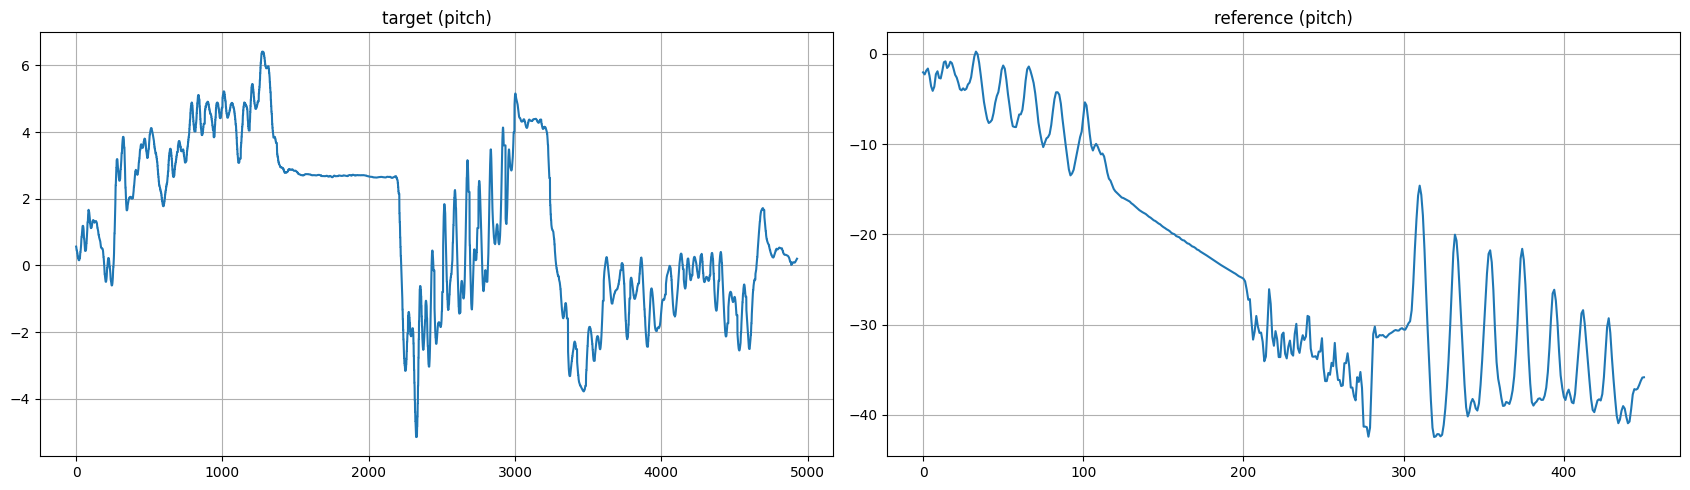

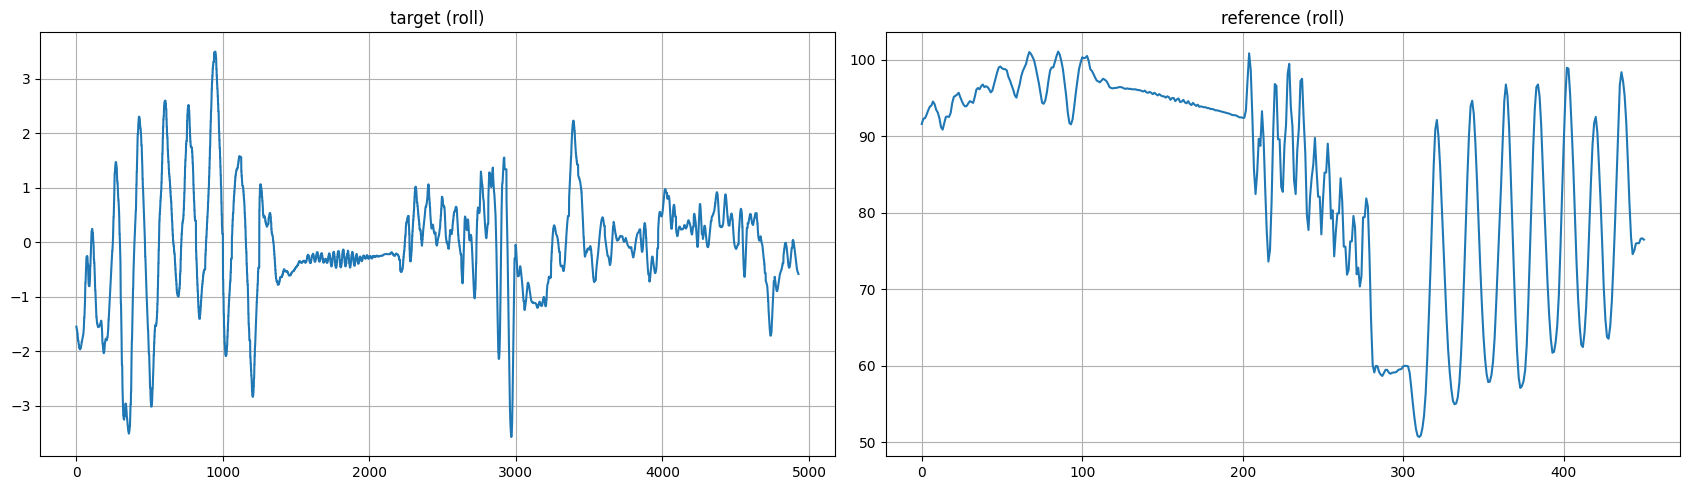

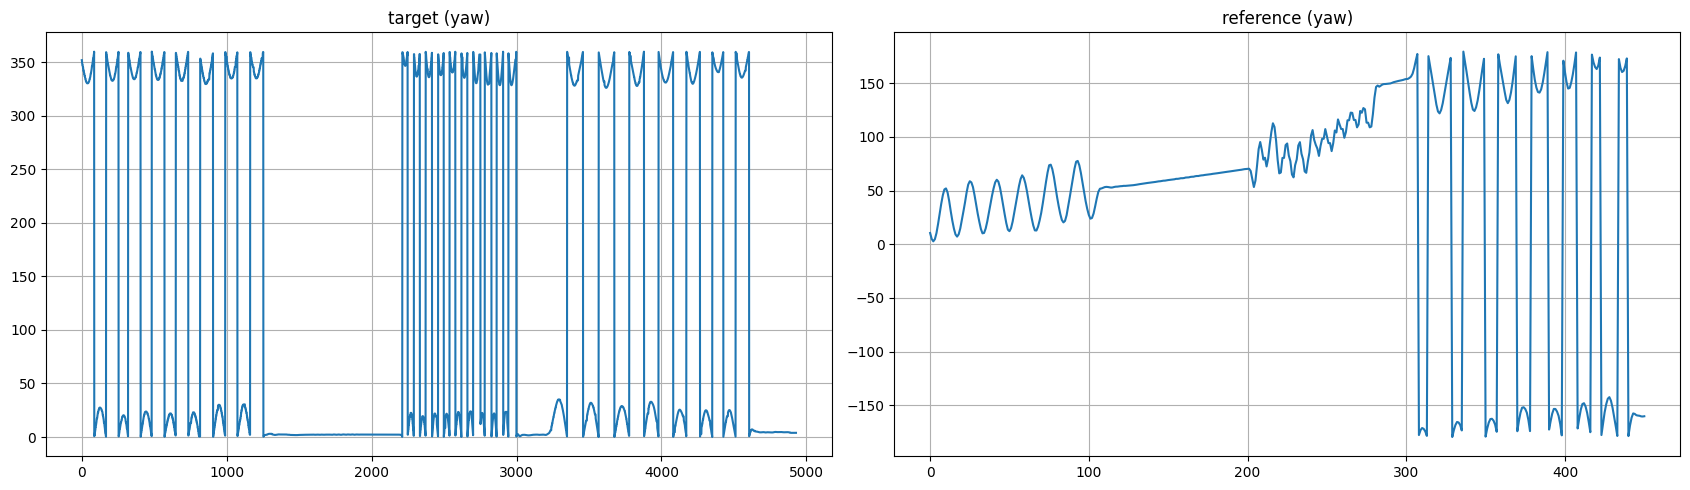

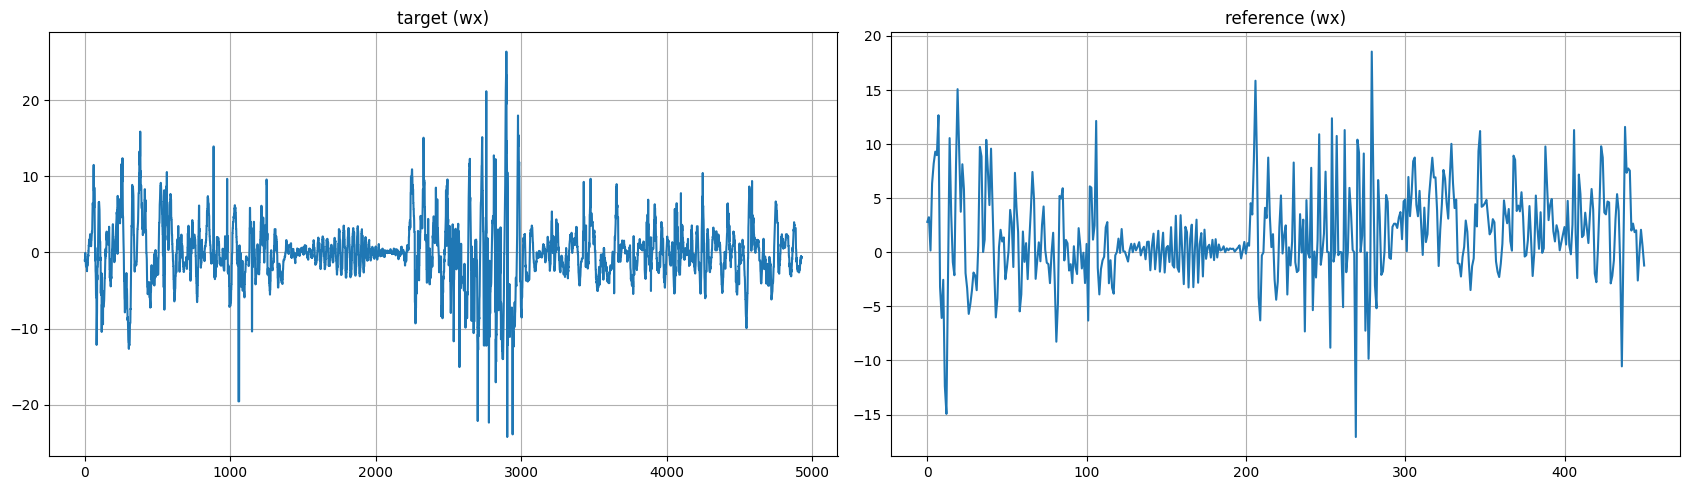

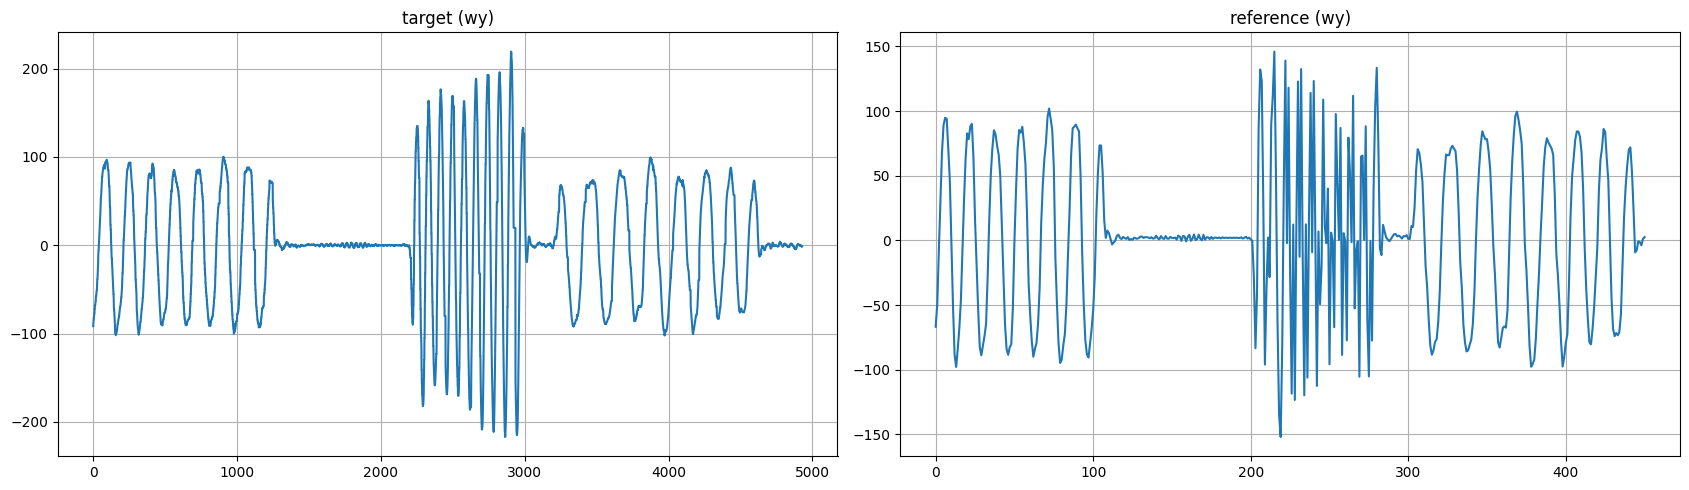

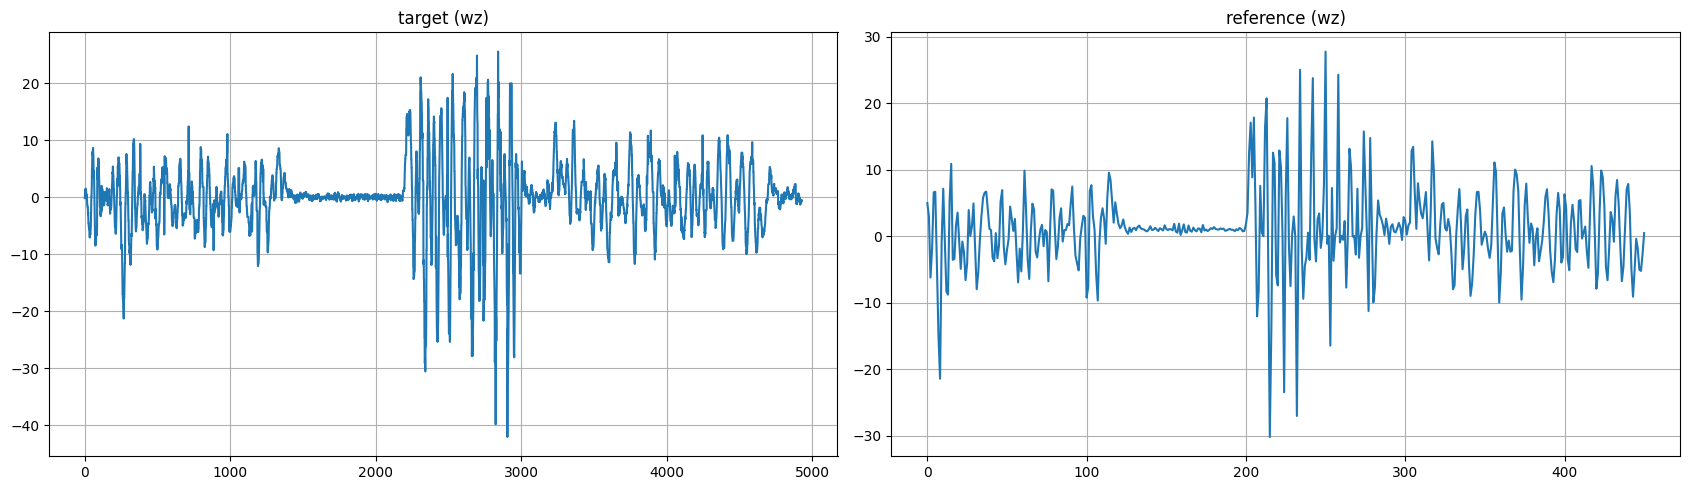

In [7]:
def compareAxis(data, figsize=None):
    count   = len(data.keys())
    numCols = 3 if count >= 3 else count
    numRows = math.ceil(count / numCols)
    plt.figure(figsize=figsize if figsize is not None else (6*numCols, 4*numRows))

    for i, (key, values) in enumerate(data.items()):
        plt.subplot(numRows, numCols, i+1)
        plt.plot(values)
        plt.title(key)
        plt.grid(True)

    plt.tight_layout()
    plt.show()


for var in ['pitch', 'roll', 'yaw', 'wx', 'wy', 'wz']:
    compareAxis({
        f'target ({var})':    df_target[f'target_{var}'], 
        f'reference ({var})': df_ref[f'ref_{var}']
    }, figsize=(17, 5))

In [8]:
first_df  = df_ref.copy() if len(df_ref) <= len(df_target) else df_target
second_df = df_ref.copy() if len(df_ref) >= len(df_target) else df_target

df = pd.merge_asof(first_df, second_df, on='time', direction='nearest')
df

,time,ref_az,ref_roll,ref_q1,ref_sample_time,ref_q3,ref_q0,ref_la_pos_mon_d,ref_wx,ref_wz,ref_ay,ref_pitch,ref_yaw,ref_q2,ref_ax,ref_wy,target_wy,target_yaw,target_pitch,target_ax,target_ay,target_q1,target_wz,target_q3,target_roll,target_q0,target_az,target_q2,target_wx,target_e
0,0.0,-0.23550,91.615951,0.7151,905000000.0,0.07618,0.6928,0.07731,2.807493,4.977284,-9.797,-2.034000,10.456480,0.053010,-0.05341,-66.749583,-91.70012,351.928,0.566,-0.204047,9.484855,0,-0.12853,0,-1.547,0,0.805861,0,-1.04879,0.0
1,0.1,-0.44210,92.303501,0.7209,5000000.0,0.04384,0.6915,0.08007,3.242368,2.971932,-9.735,-2.264902,4.897070,0.017120,-0.41220,-49.537931,-71.89229,342.952,0.293,-0.263005,9.898479,0,0.12185,0,-1.759,0,0.539964,0,-1.88971,0.0
2,0.2,-0.65480,92.360797,0.7216,105000000.0,0.02795,0.6918,0.08320,0.164324,-6.210862,-9.783,-1.840340,2.709517,0.005945,0.07146,-8.771984,-58.17557,337.082,0.157,-0.523665,9.480785,0,-1.76192,0,-1.928,0,0.254532,0,-1.21886,0.0
3,0.3,-0.55400,92.819163,0.7240,205000000.0,0.03840,0.6884,0.08568,6.359832,-1.837476,-9.898,-1.617460,4.685649,0.019880,0.27240,29.077608,-38.35434,332.095,0.405,-0.987853,9.614773,0,-5.45139,0,-1.940,0,0.279097,0,1.43899,0.0
4,0.4,-0.42470,93.392121,0.7259,305000000.0,0.07717,0.6816,0.08755,8.199026,6.583285,-9.899,-2.400693,10.370536,0.051460,0.18020,67.895499,0.49075,330.255,0.981,-0.356040,9.951533,0,-5.83280,0,-1.789,0,0.090123,0,1.05716,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
446,44.6,0.17720,76.031499,0.1422,505000000.0,0.69970,-0.3265,10.00000,-2.610969,-1.883885,-9.654,-37.116206,-159.396859,0.619400,0.04383,-0.700727,40.60773,23.407,-1.184,0.695566,9.926576,0,-6.95774,0,0.381,0,-0.559028,0,2.44324,0.0
447,44.7,-0.06857,76.031499,0.1406,605000000.0,0.70150,-0.3236,10.00000,-0.101757,-5.032288,-9.772,-36.720865,-159.568746,0.619200,-0.02459,-1.295458,-8.29896,25.142,-0.815,1.399144,9.948533,0,-0.75012,0,0.523,0,-0.578347,0,0.08862,0.0
448,44.8,-0.17420,76.604457,0.1389,705000000.0,0.70150,-0.3187,10.00000,2.079264,-5.209905,-9.621,-36.256769,-160.141704,0.622200,-0.03938,-3.759749,-47.59066,22.021,-0.880,0.624380,9.882681,0,2.96320,0,0.337,0,-0.250913,0,-5.13846,0.0
449,44.9,-0.07313,76.661753,0.1369,805000000.0,0.70240,-0.3161,10.00000,0.558405,-2.673994,-9.902,-35.884347,-160.256295,0.622800,0.26430,1.200920,-72.14091,15.951,-1.098,0.349382,9.600220,0,0.30823,0,-0.018,0,0.205410,0,-3.42173,0.0


In [9]:
df.to_csv('output.csv', index=None)